In this chapter, we will have a basic visualization of the data we just downloaded

# Visualizing urban climate data from a GeoPackage (.gpkg)
We assuem the GeoPackage contains:
- a geometry column
- a numeric climate variable
- optionally a time or city identifier

Simple plot

        AGS       GEN   NUTS     Shape_Leng    Shape_Area  \
0  09563000     Fürth  DE253   49209.551437  6.334375e+07   
1  09162000   München  DE212  118084.194383  3.108342e+08   
2  09461000   Bamberg  DE241   44492.667416  5.464215e+07   
3  09262000    Passau  DE222   61360.769487  6.956591e+07   
4  09564000  Nürnberg  DE254  153997.952475  1.866370e+08   

   Pop_Benefit_Percent                                           geometry  
0            49.550707  MULTIPOLYGON (((4392577.758 2936451.016, 43926...  
1            70.270877  MULTIPOLYGON (((4432133.707 2774479.63, 443212...  
2            77.048748  MULTIPOLYGON (((4388203.406 2978639.586, 43882...  
3            78.069768  MULTIPOLYGON (((4570163.06 2838978.815, 457018...  
4            46.746620  MULTIPOLYGON (((4401927.814 2917518.273, 44019...  
Index(['AGS', 'GEN', 'NUTS', 'Shape_Leng', 'Shape_Area', 'Pop_Benefit_Percent',
       'geometry'],
      dtype='object')


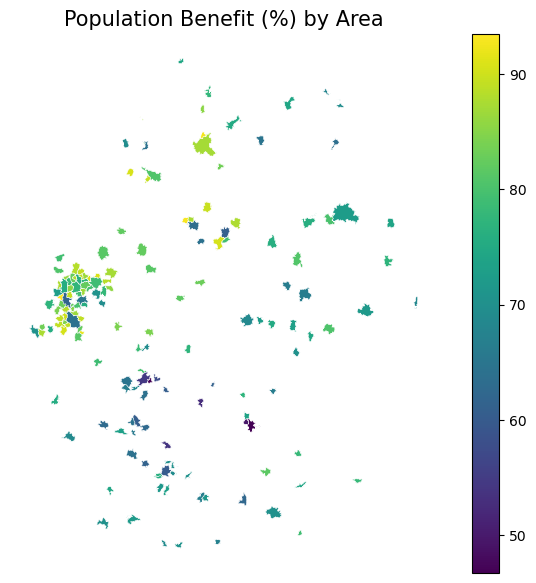

In [9]:

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

#1. load the GeoPackage file
gdf = gpd.read_file ("../../00_data/downloaded_data/climate_regulation_in_cities.gpkg" )

#2. inspect the data structure
print(gdf.head())
print(gdf.columns)

# 3) Pick a numeric column to visualize (here: Pop_Benefit_Percent)
value_col = "Pop_Benefit_Percent"

# Safety check (prevents KeyError)
if value_col not in gdf.columns:
    raise ValueError(
        f"Column '{value_col}' not found. Available columns: {list(gdf.columns)}"
    )

# 4) Ensure the chosen column is numeric (sometimes it loads as text)
gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")

# 5) Create a readable map plot
fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",          # readable, colorblind-friendly for many viewers
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

# 6) Add a clear title (and optional subtitle-style info)
ax.set_title("Population Benefit (%) by Area", fontsize=15)
ax.set_axis_off()

plt.show()

